# Load groundwork 

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as colors

import scanpy as sc

import os

import scvi

import seaborn as sns

%matplotlib inline

def order_m(m):
    n = min(*m.shape)
    
    ordered_cols = []
    remain_cols = list(range(m.shape[1]))
    
    for i in range(n):
        ic = m[i, remain_cols].argmax()
        c = remain_cols[ic]
        ordered_cols.append(c)
        remain_cols.remove(c)
    
    return ordered_cols, remain_cols




canonical_markers = ["IL32", "LTB", "CD3D",
    "IL7R", "LDHB", "FCGR3A", 
    "CD68", "MS4A1", "GNLY", 
    "CD3E", "CD14", "CD14", 
    "FCGR3A", "LYZ", "PPBP", 
    "CD8A", "PPBP", "CST3", 
    "NKG7", "MS4A7", "MS4A1", 
    "CD8A", "CD4", "NCAM1"]

    

/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing CSCDataset from `anndata.experimental` is deprecated. Import anndata.abc.CSCDataset instead.
  warnings.warn(msg, FutureWarning)
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndat

In [2]:
## Downloaded CR-arc count matrix results
data_dir = '/mnt/hdd_bob/syy/adipose/atac/protocol_benchmark/downloaded_counts/VIB_10xmultiome_2'

h5_file = os.path.join(data_dir, 'GSM7102997_VIB_10xmultiome_2-outs-raw_feature_bc_matrix-matrix.h5ad')

barcodes_file = os.path.join(data_dir, 'GSM7102997_VIB_10xmultiome_2.barcodes.tsv')

features_file = os.path.join(data_dir, 'GSM7102997_VIB_10xmultiome_2.features.tsv')

h5 = sc.read_h5ad(h5_file)

features_pd = pd.read_csv(features_file, header=None, sep='\t')

barcodes_pd = pd.read_csv(barcodes_file, header=None, sep='\t')

## It's feature -by- barcode matrix, need to transpose
h5.var = barcodes_pd
h5.obs = features_pd 
h5.obs.columns = ['feature_id', 'name', 'feature_type', 'chrom', 'start', 'end']
h5.var.columns = ['barcodes']


## Entropy filtered atac
entropy_dir = '/mnt/hdd_bob/syy/adipose/atac/res/VIB_10xmultiome_2_WS3000F'
entropy_downstream_dir = os.path.join(entropy_dir, 'DownstreamReanalysis')
entropy_peak_file = os.path.join(entropy_downstream_dir, 'entropy_peakvi.h5ad')
peak_file = os.path.join(entropy_downstream_dir, 'peakvi.h5ad')

entropy_peak = sc.read_h5ad(entropy_peak_file)
peak = sc.read_h5ad(peak_file)

# Rename peakvi clustering columns
entropy_peak.obs['clusters_peakvi_entropy'] = entropy_peak.obs['clusters_peakvi']
peak.obs['clusters_peakvi_standard'] = peak.obs['clusters_peakvi']

# Load entropy score and add to entropy_peak obs
entropy_score_file = os.path.join(entropy_dir, 'entropy_filtered_bc_df.tsv')
entropy_score_pd = pd.read_csv(entropy_score_file, sep=',', index_col=0)
entropy_peak.obs = entropy_peak.obs.merge(entropy_score_pd[['Entropy', 'Entropy_open_region']], left_on='barcodes', right_index=True, how='left')

# atac clsutering at higher resolutions (than previously used)
atac_resolution = 0.5
sc.tl.leiden(entropy_peak, key_added='clusters_peakvi_highres_entropy', resolution=atac_resolution)
sc.tl.leiden(peak, key_added='clusters_peakvi_highres_standard', resolution=atac_resolution)


# atac-rna-barcode map 
bc_map_file = '/home/syyang/adipose_ln/multiom/atac_rna_barcodes_map.tsv'
bc_map_pd = pd.read_csv(bc_map_file, sep='\t')




## load peakvi models for DARS analysis 
standard_peak_model_dir = os.path.join(entropy_downstream_dir, 'standard_peak_peakvi_model')
entropy_peak_model_dir =os.path.join(entropy_downstream_dir, 'entropy_peak_peakvi_model')
standard_peak_model =scvi.model.PEAKVI.load(standard_peak_model_dir, adata=peak)
entropy_peak_model =scvi.model.PEAKVI.load(entropy_peak_model_dir, adata=entropy_peak)


# Summary statistics about Fraction of Reads in Peaks (FRIP)
standard_peak_frip_file = os.path.join(entropy_dir, 'fragments_overlap_peaks', 'summary_statistics_frag_overlap_peaks.csv')
entropy_peak_frip_file = os.path.join(entropy_dir, 'fragments_overlap_peaks', 'summary_statistics_frag_overlap_entropypeaks.csv')


standard_peak_frip = pd.read_csv(standard_peak_frip_file, index_col=None, sep='\t')
entropy_peak_frip = pd.read_csv(entropy_peak_frip_file, index_col=None, sep='\t')
standard_peak_frip.rename(columns={'1': 'barcode'}, inplace=True)
entropy_peak_frip.rename(columns={'1': 'barcode'}, inplace=True)
entropy_peak_frip['atac_bc'] = entropy_peak_frip['barcode'].str.split('-1').str[0]
standard_peak_frip['atac_bc'] = standard_peak_frip['barcode'].str.split('-1').str[0]
standard_peak_frip.set_index('atac_bc', inplace=True)
entropy_peak_frip.set_index('atac_bc', inplace=True)

/tmp/ipykernel_1289913/4248593922.py:43: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(entropy_peak, key_added='clusters_peakvi_highres_entropy', resolution=atac_resolution)


INFO     File                                                                                                      
         /mnt/hdd_bob/syy/adipose/atac/res/VIB_10xmultiome_2_WS3000F/DownstreamReanalysis/standard_peak_peakvi_mode
         l/model.pt already downloaded                                                                             
INFO     File                                                                                                      
         /mnt/hdd_bob/syy/adipose/atac/res/VIB_10xmultiome_2_WS3000F/DownstreamReanalysis/entropy_peak_peakvi_model
         /model.pt already downloaded                                                                              


/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/scvi/model/base/_save_load.py:76: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = torch.load(model_

# RNA clustering

In [6]:
h5_rna, h5_rna_.shape

(AnnData object with n_obs × n_vars = 2125 × 36588
     obs: 'barcodes', 'atac_bc', 'total_RNA_UMI', 'total_RNA_UMI_log', 'n_genes_by_RNA_counts', 'N_MT_counts', 'MT%'
     var: 'feature_id', 'name', 'feature_type', 'chrom', 'start', 'end', 'gene_name'
     layers: 'log1p_counts',
 (2125, 36601))

###  Reorder cluster-order in entropy_peak to match for color in standard_peak

In [31]:
# Reference is 'clusters_peakvi_highres_standard'
relate_labels2 = h5_rna.obs.groupby(['clusters_peakvi_highres_standard', 'clusters_peakvi_highres_entropy']).size().unstack(fill_value=0)
ordered_col, remained_col = order_m(relate_labels2.values)

# # Now map the best matching clusters
h5_rna.obs['reorder_clusters_peakvi_highres_entropy'] = h5_rna.obs['clusters_peakvi_highres_entropy'].cat.reorder_categories([str(i) for i in ordered_col+remained_col], ordered=False)

h5_rna.obs.groupby(['clusters_peakvi_highres_standard', 'reorder_clusters_peakvi_highres_entropy']).size().unstack(fill_value=0)


/tmp/ipykernel_1289913/1301716670.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  relate_labels2 = h5_rna.obs.groupby(['clusters_peakvi_highres_standard', 'clusters_peakvi_highres_entropy']).size().unstack(fill_value=0)
/tmp/ipykernel_1289913/1301716670.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  h5_rna.obs.groupby(['clusters_peakvi_highres_standard', 'reorder_clusters_peakvi_highres_entropy']).size().unstack(fill_value=0)


reorder_clusters_peakvi_highres_entropy,0,1,2,4,3,5,8,7,12,11,10,6,9
clusters_peakvi_highres_standard,,,,,,,,,,,,,
0,306,0,3,0,13,0,0,0,0,1,0,0,76
1,0,278,0,0,0,0,0,0,0,2,1,18,0
2,0,0,243,0,0,1,2,4,0,1,0,0,13
3,0,8,0,126,0,0,0,0,0,0,2,124,0
4,10,0,0,0,178,0,0,1,0,0,0,0,0
5,0,0,0,0,1,141,0,0,0,1,40,0,0
6,0,0,12,0,0,0,108,31,0,0,0,0,0
7,1,0,2,0,20,0,0,99,0,0,0,0,4
8,0,0,0,47,7,0,0,0,55,1,0,0,0


# Load peak info -- (rediscovered, newly-discovred, or lost labels)

In [35]:
peak_comparison_dir = os.path.join(entropy_dir, 'peaks_comparison')
lost_peaks_anno_file = os.path.join(peak_comparison_dir, 'lost_peaks.bed')
newly_discovered_peaks_anno_file = os.path.join(peak_comparison_dir, 'newly_discovered_peaks.bed')
recovered_peaks_anno_file = os.path.join(peak_comparison_dir, 'recovered_peaks.bed')

lost_peaks_anno = pd.read_csv(lost_peaks_anno_file, header=None, sep='\t')  # Correspond to Standard peaks called using all the reads
newly_discovered_peaks_anno = pd.read_csv(newly_discovered_peaks_anno_file, header=None, sep='\t') # Correspond to Entropy peaks called using only the reads retained after entropy filtering
recovered_peaks_anno = pd.read_csv(recovered_peaks_anno_file, header=None, sep='\t') # In both peak sets [first half of the columns are from Standard peaks, second half from Entropy peaks]

columns_set = ['chrom', 'chromStart', 'chromEnd', 'name', 'peak_auc_score', 'strand', 'signalValue', 'pValue', 'qValue', 'peak']
columns_set_c2 = columns_set + [i + '_entropy' for i in columns_set] + ['overlap_length']


lost_peaks_anno.columns = columns_set
newly_discovered_peaks_anno.columns = columns_set
recovered_peaks_anno.columns = columns_set_c2


## Check Peak specificity at cell level

In [108]:
peak.var['recovered'] = peak.var['peak'].isin(recovered_peaks_anno['Standard_peak'])
peak.var['lost'] = peak.var['peak'].isin(lost_peaks_anno.index)
peak.var['peak_type'] = peak.var.apply(lambda x: 'recovered' if x['recovered'] else ('lost' if x['lost'] else 'others'), axis=1)


entropy_peak.var['recovered'] = entropy_peak.var['peak'].isin(recovered_peaks_anno['Entropy_peak'])
entropy_peak.var['newly_discovered'] = entropy_peak.var['peak'].isin(newly_discovered_peaks_anno.index)
entropy_peak.var['peak_type'] = entropy_peak.var.apply(lambda x: 'recovered' if x['recovered'] else ('newly_discovered' if x['newly_discovered'] else 'others'), axis=1)

In [109]:
peak.var['presence_in_Ncells'] = (peak.X > 0).sum(axis=0).A.reshape(-1)
entropy_peak.var['presence_in_Ncells'] = (entropy_peak.X > 0).sum(axis=0).A.reshape(-1)

# Both standard-peak and entropy-peak have same number of cells (2125)
peak.var['specificity_score'] = 1 - (peak.var['presence_in_Ncells'] / peak.shape[0])
entropy_peak.var['specificity_score'] = 1 - (entropy_peak.var['presence_in_Ncells'] / entropy_peak.shape[0])

In [114]:
entropy_peak.var.loc[entropy_peak.var['peak_type'] == 'newly_discovered', 'specificity_score'].describe()

count    6139.000000
mean        0.970937
std         0.006631
min         0.914353
25%         0.968471
50%         0.971294
75%         0.973647
max         1.000000
Name: specificity_score, dtype: float64

Text(0, 0.5, 'Count')

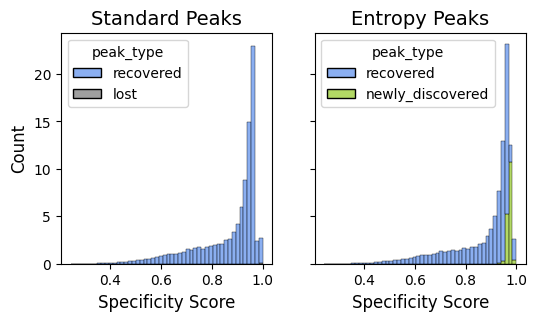

In [ ]:
color_maps = {'recovered': 'cornflowerblue', 'lost': 'grey', 'newly_discovered': 'yellowgreen', 'others': 'red'}

fig, ax = plt.subplots(1, 2, figsize=(6,3), sharex=True, sharey=True)
sns.histplot(data=peak.var, x='specificity_score', hue='peak_type', 
             stat="percent",common_norm=True,  palette=color_maps, 
             multiple='stack', bins=50, ax=ax[0])
ax[0].set_title('Standard Peaks', fontsize=14)
ax[0].set_xlabel('Specificity Score', fontsize=12)
ax[0].set_ylabel('Count', fontsize=12)

sns.histplot(data=entropy_peak.var, x='specificity_score', hue='peak_type',
                stat="percent",common_norm=True, palette=color_maps,
                multiple='stack', bins=50, ax=ax[1])
ax[1].set_title('Entropy Peaks', fontsize=14)
ax[1].set_xlabel('Specificity Score', fontsize=12)
ax[1].set_ylabel('Count', fontsize=12)


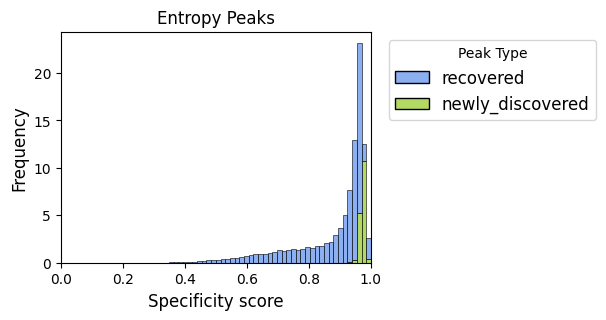

In [145]:
color_maps = {'recovered': 'cornflowerblue', 'lost': 'grey', 'newly_discovered': 'yellowgreen', 'others': 'red'}

fig, ax = plt.subplots( figsize=(4,3))


sns.histplot(data=entropy_peak.var, x='specificity_score', hue='peak_type',
                stat="percent",common_norm=True, palette=color_maps, hue_order=[  'recovered', 'newly_discovered',],
                multiple='stack', bins=50, ax=ax)
ax.set_title('Entropy Peaks', fontsize=12)
ax.set_xlabel('Specificity score', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_xlim(0, 1)
sns.move_legend(ax, "upper left", bbox_to_anchor=(1.03, 1), title='Peak Type', fontsize=12)

Text(0.5, 0.98, 'Standard Peaks')

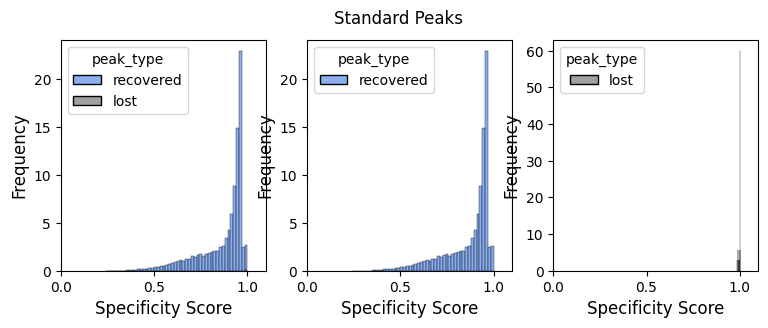

In [160]:
color_maps = {'recovered': 'cornflowerblue', 'lost': 'grey', 'newly_discovered': 'yellowgreen', 'others': 'red'}


fig, ax = plt.subplots(1, 3, figsize=(9,3), sharex=False, sharey=False)
sns.histplot(data=peak.var, x='specificity_score', hue='peak_type',
                stat="percent",common_norm=True, palette=color_maps,
                multiple='stack', bins=50, ax=ax[0])
# ax[0].set_title('Standard Peaks', fontsize=14)
ax[0].set_xlabel('Specificity Score', fontsize=12)
ax[0].set_ylabel('Frequency', fontsize=12)


sns.histplot(data=peak.var.loc[peak.var['peak_type'] == 'recovered'], x='specificity_score',  hue='peak_type',
             stat="percent",common_norm=True,  palette=color_maps,
             multiple='stack', bins=50, ax=ax[1])
# ax[1].set_title('Standard Peaks', fontsize=14)
ax[1].set_xlabel('Specificity Score', fontsize=12)
ax[1].set_ylabel('Frequency', fontsize=12)

sns.histplot(data=peak.var.loc[peak.var['peak_type'] == 'lost'], x='specificity_score', hue='peak_type',
                stat="percent",common_norm=True, palette=color_maps,
                multiple='stack', bins=50, ax=ax[2])
# ax[2].set_title('Standard Peaks', fontsize=14)
ax[2].set_xlabel('Specificity Score', fontsize=12)
ax[2].set_ylabel('Frequency', fontsize=12)


for i in range(3):
    ax[i].set_xlim(0, 1.1)
    #sns.move_legend(ax[i], "upper left", bbox_to_anchor=(3.03 - i, 1), title='Peak Type', fontsize=12)
    
fig.suptitle('Standard Peaks', fontsize=12)

## Check Peak specificity at ATAC cluster level

In [37]:
####
# For standard peaks
standard_peak_at_cluster_level = pd.DataFrame(index=peak.var['peak'], columns=peak.obs['clusters_peakvi_higherres_standard'].cat.categories)
for c in peak.obs['clusters_peakvi_higherres_standard'].cat.categories:
    a = peak[peak.obs['clusters_peakvi_higherres_standard'] == c, :].X.sum(axis=0 )
    standard_peak_at_cluster_level[c] = np.asarray(a).flatten()


standard_peak_at_cluster_level_h5ad = sc.AnnData(standard_peak_at_cluster_level.T)

standard_peak_at_cluster_level_h5ad.var['recovered'] = standard_peak_at_cluster_level_h5ad.var.index.isin(recovered_peaks_anno['Standard_peak'])
standard_peak_at_cluster_level_h5ad.var['lost'] = standard_peak_at_cluster_level_h5ad.var.index.isin(lost_peaks_anno.index)
standard_peak_at_cluster_level_h5ad.var['peak_type'] = standard_peak_at_cluster_level_h5ad.var.apply(lambda x: 'recovered' if x['recovered'] else ('lost' if x['lost'] else 'others'), axis=1)

####
# For entropy peaks
entropy_peak_at_cluster_level = pd.DataFrame(index=entropy_peak.var['peak'], columns=entropy_peak.obs['clusters_peakvi_highres_entropy'].cat.categories)
for c in entropy_peak.obs['clusters_peakvi_highres_entropy'].cat.categories:
    a = entropy_peak[entropy_peak.obs['clusters_peakvi_highres_entropy'] == c, :].X.sum(axis=0 )
    entropy_peak_at_cluster_level[c] = np.asarray(a).flatten()
    
entropy_peak_at_cluster_level_h5ad = sc.AnnData(entropy_peak_at_cluster_level.T)

entropy_peak_at_cluster_level_h5ad.var['recovered'] = entropy_peak_at_cluster_level_h5ad.var.index.isin(recovered_peaks_anno['Entropy_peak'])
entropy_peak_at_cluster_level_h5ad.var['newly_discovered'] = entropy_peak_at_cluster_level_h5ad.var.index.isin(newly_discovered_peaks_anno.index)
entropy_peak_at_cluster_level_h5ad.var['peak_type'] = entropy_peak_at_cluster_level_h5ad.var.apply(lambda x: 'recovered' if x['recovered'] else ('newly_discovered' if x['newly_discovered'] else 'others'), axis=1)


In [43]:
entropy_peak_at_cluster_level_h5ad, standard_peak_at_cluster_level_h5ad

(AnnData object with n_obs × n_vars = 13 × 36729
     var: 'recovered', 'newly_discovered', 'peak_type', 'presence_in_Ngroups',
 AnnData object with n_obs × n_vars = 13 × 31116
     var: 'recovered', 'lost', 'peak_type', 'presence_in_Ngroups')

In [45]:
standard_peak_at_cluster_level_h5ad.var['presence_in_Ngroups'] = (standard_peak_at_cluster_level_h5ad.X > 0).sum(axis=0)
entropy_peak_at_cluster_level_h5ad.var['presence_in_Ngroups'] = (entropy_peak_at_cluster_level_h5ad.X > 0).sum(axis=0)

# Both standard-peak and entropy-peak have same number of clusters
standard_peak_at_cluster_level_h5ad.var['specificity_score'] = 1 - (standard_peak_at_cluster_level_h5ad.var['presence_in_Ngroups'] / standard_peak_at_cluster_level_h5ad.shape[0])
entropy_peak_at_cluster_level_h5ad.var['specificity_score'] = 1 - (entropy_peak_at_cluster_level_h5ad.var['presence_in_Ngroups'] / entropy_peak_at_cluster_level_h5ad.shape[0])

In [46]:
standard_peak_at_cluster_level_h5ad.var.head()

,recovered,lost,peak_type,presence_in_Ngroups,specificity_score
peak,,,,,
chr1:817208-817719,True,False,recovered,13,0.000000
chr1:826857-828146,True,False,recovered,13,0.000000
chr1:869760-870205,True,False,recovered,13,0.000000
chr1:904403-905173,True,False,recovered,13,0.000000
chr1:906808-907046,True,False,recovered,9,0.307692


(0.0, 1.1)

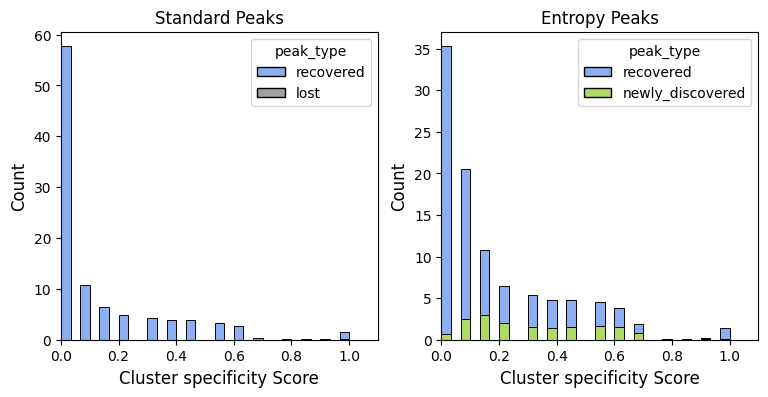

In [168]:
color_maps = {'recovered': 'cornflowerblue', 'lost': 'grey', 'newly_discovered': 'yellowgreen', 'others': 'red'}
fig, ax = plt.subplots(1, 2, figsize=(9,4))
sns.histplot(data=standard_peak_at_cluster_level_h5ad.var, x='specificity_score', hue='peak_type', 
             stat="percent",common_norm=True,  palette=color_maps,
             multiple='stack', bins=30, ax=ax[0])
ax[0].set_title('Standard Peaks', fontsize=12)
ax[0].set_xlabel('Cluster specificity Score', fontsize=12)
ax[0].set_ylabel('Count', fontsize=12)
ax[0].set_xlim(0, 1.1)

sns.histplot(data=entropy_peak_at_cluster_level_h5ad.var, x='specificity_score', hue='peak_type',
                stat="percent",common_norm=True, palette=color_maps,
                multiple='stack', bins=30, ax=ax[1])
ax[1].set_title('Entropy Peaks', fontsize=12)
ax[1].set_xlabel('Cluster specificity Score', fontsize=12)
ax[1].set_ylabel('Count', fontsize=12)
ax[1].set_xlim(0, 1.1)

### Count them up

In [39]:
standard_peak_specificity = standard_peak_at_cluster_level_h5ad.var.groupby(['presence_in_Ngroups', 'peak_type']).size().unstack(fill_value=0)

entropy_peak_specificity = entropy_peak_at_cluster_level_h5ad.var.groupby(['presence_in_Ngroups', 'peak_type']).size().unstack(fill_value=0)

standard_peak_specificity['total_peaks'] = standard_peak_specificity.sum(axis=1)
entropy_peak_specificity['total_peaks'] = entropy_peak_specificity.sum(axis=1)

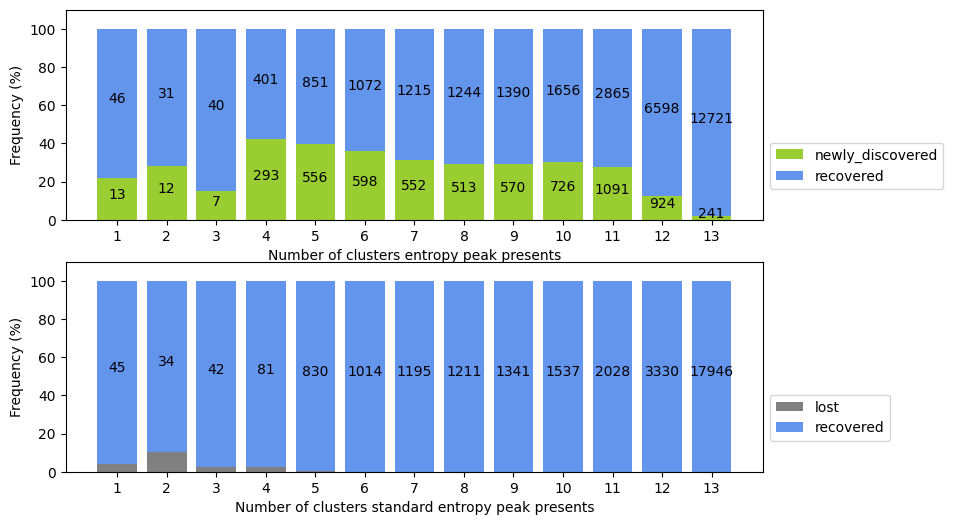

In [40]:
color_map = {'total_DARs': 'peru', 'recovered': 'cornflowerblue', 'lost': 'grey', 'newly_discovered': 'yellowgreen'}


width = 0.8  # the width of the bars
fig, ax = plt.subplots( 2, 1, figsize=(9,6))


x = np.arange(entropy_peak_specificity.shape[0])  # the label locations
bottom = np.zeros(entropy_peak_specificity.shape[0])
for attribute  in [ 'newly_discovered', 'recovered']:
    
    y_perc = entropy_peak_specificity[attribute] / entropy_peak_specificity['total_peaks'] * 100
    rects = ax[0].bar(x[1:] , y_perc[1:],  width, label=attribute, color=color_map[attribute], bottom=bottom[1:])
    bottom += y_perc
            
    value_labels = entropy_peak_specificity[attribute]
    value_pos = 'center'
    ax[0].bar_label(rects, labels=value_labels[1:] , padding=3, fontsize=10, label_type=value_pos) 


# Add some text for labels, title and custom x-axis tick labels, etc.
ax[0].set_ylabel('Frequency (%)')

ax[0].set_xlabel('Number of clusters entropy peak presents', fontsize=10) 
ax[0].set_xticks(x[1:] , standard_peak_specificity.index[1:])
ax[0].legend(loc='upper left',ncols=1, bbox_to_anchor=(1,0.4), fontsize=10)
ax[0].set_ylim(0, 100 * 1.1)
y_labels = ax[0].get_yticklabels()
y_labels[-1].set_visible(False)

x = np.arange(standard_peak_specificity.shape[0])  # the label locations
bottom = np.zeros(standard_peak_specificity.shape[0])

for attribute  in [ 'lost', 'recovered']:
    
    y_perc = standard_peak_specificity[attribute] / standard_peak_specificity['total_peaks'] * 100
    rects = ax[1].bar(x[1:] , y_perc[1:],  width, label=attribute, color=color_map[attribute], bottom=bottom[1:])
    bottom += y_perc

    value_labels = standard_peak_specificity[attribute]
    value_pos = 'center'

ax[1].bar_label(rects, labels=value_labels[1:] , padding=3, fontsize=10, label_type=value_pos) 
# Add some text for labels, title and custom x-axis tick labels, etc.
ax[1].set_ylabel('Frequency (%)')
ax[1].set_xlabel('Number of clusters standard entropy peak presents', fontsize=10) 
ax[1].set_xticks(x[1:], entropy_peak_specificity.index[1:])
ax[1].legend(loc='upper left', ncols=1, bbox_to_anchor=(1,0.4), fontsize=10)
ax[1].set_ylim(0, 100* 1.1)
y_labels = ax[1].get_yticklabels()
y_labels[-1].set_visible(False)


In [163]:
entropy_peak_specificity

peak_type,newly_discovered,recovered,total_peaks
presence_in_Ngroups,,,
0,43,460,503
1,13,46,59
2,12,31,43
3,7,40,47
4,293,401,694
5,556,851,1407
6,598,1072,1670
7,552,1215,1767
8,513,1244,1757


## Get DARs 

In [196]:
standard_DARs = {}
for cluster in peak.obs['clusters_peakvi_higherres_standard'].unique():
    print(f" DARs on StandardPeak-higherres-cluster {cluster}")
    standard_DARs[cluster] = standard_peak_model.differential_accessibility(
        groupby="clusters_peakvi_higherres_standard", group1=cluster,  two_sided=True
    )

 DARs on StandardPeak-higherres-cluster 8
DE...: 100%|██████████| 1/1 [00:05<00:00,  5.25s/it]
 DARs on StandardPeak-higherres-cluster 4
DE...: 100%|██████████| 1/1 [00:04<00:00,  4.30s/it]
 DARs on StandardPeak-higherres-cluster 9
DE...: 100%|██████████| 1/1 [00:04<00:00,  4.44s/it]
 DARs on StandardPeak-higherres-cluster 12
DE...: 100%|██████████| 1/1 [00:04<00:00,  4.34s/it]
 DARs on StandardPeak-higherres-cluster 10
DE...: 100%|██████████| 1/1 [00:04<00:00,  4.31s/it]
 DARs on StandardPeak-higherres-cluster 2
DE...: 100%|██████████| 1/1 [00:04<00:00,  4.35s/it]
 DARs on StandardPeak-higherres-cluster 6
DE...: 100%|██████████| 1/1 [00:04<00:00,  4.42s/it]
 DARs on StandardPeak-higherres-cluster 1
DE...: 100%|██████████| 1/1 [00:04<00:00,  4.50s/it]
 DARs on StandardPeak-higherres-cluster 0
DE...: 100%|██████████| 1/1 [00:04<00:00,  4.37s/it]
 DARs on StandardPeak-higherres-cluster 5
DE...: 100%|██████████| 1/1 [00:04<00:00,  4.32s/it]
 DARs on StandardPeak-higherres-cluster 3
DE...:

In [202]:
relate_labels2 = h5_rna.obs.groupby(['clusters_peakvi_highres_standard', 'clusters_peakvi_highres_entropy']).size().unstack(fill_value=0)
ordered_col, remained_col = order_m(relate_labels2.values)

# # Now map the best matching clusters
entropy_peak.obs['reorder_clusters_peakvi_highres_entropy'] = entropy_peak.obs['clusters_peakvi_highres_entropy'].cat.reorder_categories([str(i) for i in ordered_col+remained_col], ordered=False)


/tmp/ipykernel_1045041/1564788879.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  relate_labels2 = h5_rna.obs.groupby(['clusters_peakvi_highres_standard', 'clusters_peakvi_highres_entropy']).size().unstack(fill_value=0)


In [203]:
entropy_DARs = {}
for cluster in entropy_peak.obs['reorder_clusters_peakvi_highres_entropy'].unique():
    print(f" DARs on EntropyPeak-highres-cluster {cluster}")
    entropy_DARs[cluster] = entropy_peak_model.differential_accessibility(
        groupby="reorder_clusters_peakvi_highres_entropy", group1=cluster,  two_sided=True
    )

 DARs on EntropyPeak-highres-cluster 11
DE...: 100%|██████████| 1/1 [00:05<00:00,  5.10s/it]
 DARs on EntropyPeak-highres-cluster 12
DE...: 100%|██████████| 1/1 [00:05<00:00,  5.23s/it]
 DARs on EntropyPeak-highres-cluster 5
DE...: 100%|██████████| 1/1 [00:05<00:00,  5.29s/it]
 DARs on EntropyPeak-highres-cluster 1
DE...: 100%|██████████| 1/1 [00:05<00:00,  5.19s/it]
 DARs on EntropyPeak-highres-cluster 9
DE...: 100%|██████████| 1/1 [00:05<00:00,  5.29s/it]
 DARs on EntropyPeak-highres-cluster 2
DE...: 100%|██████████| 1/1 [00:05<00:00,  5.15s/it]
 DARs on EntropyPeak-highres-cluster 4
DE...: 100%|██████████| 1/1 [00:05<00:00,  5.26s/it]
 DARs on EntropyPeak-highres-cluster 0
DE...: 100%|██████████| 1/1 [00:05<00:00,  5.13s/it]
 DARs on EntropyPeak-highres-cluster 8
DE...: 100%|██████████| 1/1 [00:05<00:00,  5.17s/it]
 DARs on EntropyPeak-highres-cluster 3
DE...: 100%|██████████| 1/1 [00:05<00:00,  5.21s/it]
 DARs on EntropyPeak-highres-cluster 6
DE...: 100%|██████████| 1/1 [00:05<00:0

In [204]:
## manually change effect-size sign 

for cluster in entropy_DARs.keys():
    entropy_DARs[cluster]['effect_size_correct_sign'] = -entropy_DARs[cluster]['effect_size']
    
for cluster in standard_DARs.keys():
    standard_DARs[cluster]['effect_size_correct_sign'] = -standard_DARs[cluster]['effect_size']

## Label peak types for DARs

### sub 1

In [205]:

for key in entropy_DARs.keys():

    id = entropy_DARs[key].index.values 
    entropy_DARs[key]['Entropy_peak'] = entropy_peak.var.loc[id, 'peak']
    entropy_DARs[key]['lost_peak'] = entropy_DARs[key]['Entropy_peak'].isin(lost_peaks_anno.index)
    entropy_DARs[key]['newly_discovered_peak'] = entropy_DARs[key]['Entropy_peak'].isin(newly_discovered_peaks_anno.index)
    entropy_DARs[key]['recovered_peak'] = entropy_DARs[key]['Entropy_peak'].isin(recovered_peaks_anno["Entropy_peak"])


for key in standard_DARs.keys():
    
    id = standard_DARs[key].index.values
    standard_DARs[key]['Standard_peak'] = peak.var.loc[id, 'peak']
    standard_DARs[key]['lost_peak'] = standard_DARs[key]['Standard_peak'].isin(lost_peaks_anno.index)
    standard_DARs[key]['newly_discovered_peak'] = standard_DARs[key]['Standard_peak'].isin(newly_discovered_peaks_anno.index)
    standard_DARs[key]['recovered_peak'] = standard_DARs[key]['Standard_peak'].isin(recovered_peaks_anno["Standard_peak"])

In [216]:
def create_DARs_stats(DARs_stats_dict, index_name):
    DAR_stats_df = pd.DataFrame(columns=['total_DARs', 'DARs_in_recovered_peaks', 'DARs_in_lost_peaks', 'DARs_in_newly_discovered_peaks'])
    
    for key in DARs_stats_dict.keys():
        NDAR_in_recovered = DARs_stats_dict[key].loc[DARs_stats_dict[key]['is_da_fdr'], 'recovered_peak'].sum()
        NDAR_in_lost = DARs_stats_dict[key].loc[DARs_stats_dict[key]['is_da_fdr'], 'lost_peak'].sum()
        NDAR_in_newly_discovered = DARs_stats_dict[key].loc[DARs_stats_dict[key]['is_da_fdr'], 'newly_discovered_peak'].sum()
        
        DAR_stats_df.loc[key, 'total_DARs'] = DARs_stats_dict[key]['is_da_fdr'].sum()
        DAR_stats_df.loc[key, 'DARs_in_recovered_peaks'] = NDAR_in_recovered
        DAR_stats_df.loc[key, 'DARs_in_lost_peaks'] = NDAR_in_lost
        DAR_stats_df.loc[key, 'DARs_in_newly_discovered_peaks'] = NDAR_in_newly_discovered
        
    DAR_stats_df.index.name = index_name
    
    return DAR_stats_df

In [217]:
entropy_DARs_stats = create_DARs_stats(entropy_DARs, index_name='Entropy_peak_cluster')
standard_DARs_stats = create_DARs_stats(standard_DARs, index_name='Standard_peak_cluster')


standard_DARs_stats_perc = standard_DARs_stats.div(standard_DARs_stats['total_DARs'], axis=0) * 100
standard_DARs_stats_perc.columns = [col + '_perc' for col in standard_DARs_stats_perc.columns]
standard_DARs_stats_perc['total_DARs'] = standard_DARs_stats['total_DARs'] # add back total_DARs column for reference


entropy_DARs_stats_perc = entropy_DARs_stats.div(entropy_DARs_stats['total_DARs'], axis=0) * 100
entropy_DARs_stats_perc.columns = [col + '_perc' for col in entropy_DARs_stats_perc.columns]
entropy_DARs_stats_perc['total_DARs'] = entropy_DARs_stats['total_DARs'] # add back total_DARs column for reference

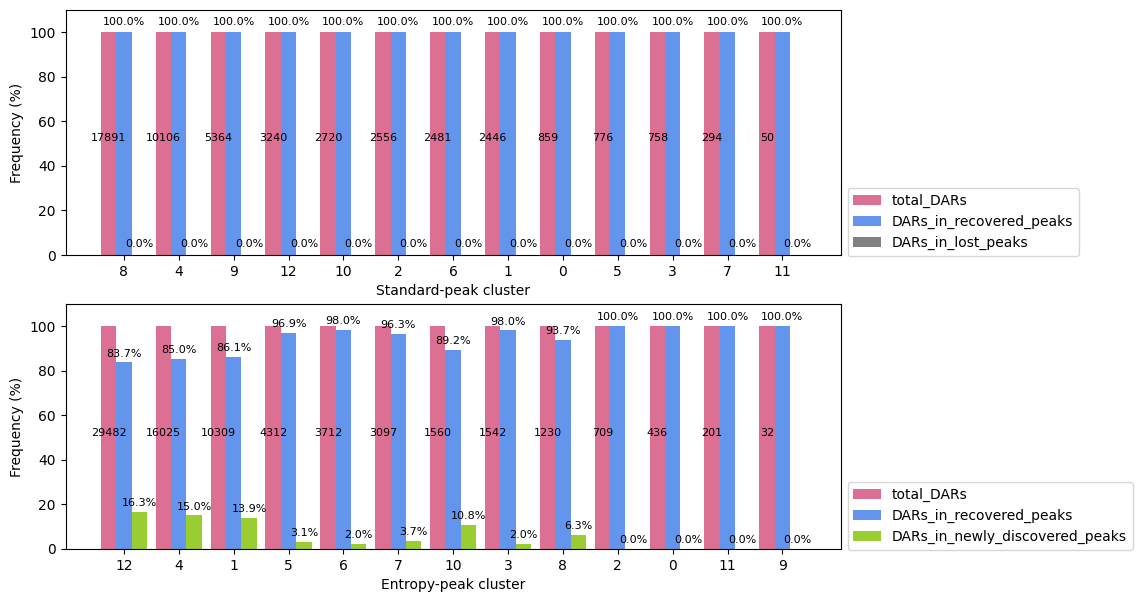

In [328]:
color_map = {'total_DARs': 'palevioletred', 'DARs_in_recovered_peaks': 'cornflowerblue', 'DARs_in_lost_peaks': 'grey', 'DARs_in_newly_discovered_peaks': 'yellowgreen'}


plot_order_by_total_DARs = standard_DARs_stats.sort_values(by='total_DARs', ascending=False).index.values 
standard_DARs_stats2 = standard_DARs_stats.loc[plot_order_by_total_DARs]
standard_DARs_stats_perc2 = standard_DARs_stats_perc.loc[plot_order_by_total_DARs]

plot_order_by_total_DARs = entropy_DARs_stats.sort_values(by='total_DARs', ascending=False).index.values
entropy_DARs_stats2 = entropy_DARs_stats.loc[plot_order_by_total_DARs]
entropy_DARs_stats_perc2 = entropy_DARs_stats_perc.loc[plot_order_by_total_DARs]



width = 0.28  # the width of the bars
fig, ax = plt.subplots(2, 1, figsize=(10,7))

x = np.arange(standard_DARs_stats2.shape[0])  # the label locations
multiplier = 0
for attribute  in ['total_DARs', 'DARs_in_recovered_peaks', 'DARs_in_lost_peaks']:
    offset = width * multiplier
    rects = ax[0].bar(x + offset, standard_DARs_stats_perc2[attribute+'_perc'], width, label=attribute, color=color_map[attribute])
    if attribute == 'total_DARs':
        value_labels = standard_DARs_stats2[attribute].values
        value_pos = 'center'
        ax[0].bar_label(rects, labels=value_labels , padding=4, fontsize=8, label_type=value_pos) 

    else:
        value_labels = standard_DARs_stats_perc2[attribute+'_perc']
        value_pos = 'edge'
        ax[0].bar_label(rects, labels=[f'{x:,.1f}%' for x in value_labels] , padding=4, fontsize=8, label_type=value_pos) 

    multiplier += 1

# Add some text for labels, title and custom x-axis tick labels, etc.
ax[0].set_ylabel('Frequency (%)')
# ax[0].set_title('Standard-Peak cluster DARs statistics')
ax[0].set_xlabel('Standard-peak cluster')
ax[0].set_xticks(x + width, standard_DARs_stats.index)
ax[0].legend(loc='upper left', ncols=1, bbox_to_anchor=(1,0.3), fontsize=10)
ax[0].set_ylim(0, 100 * 1.1)
y_labels = ax[0].get_yticklabels()
y_labels[-1].set_visible(False)



# for attribute  in entropy_DARs_stats.columns:
x = np.arange(entropy_DARs_stats2.shape[0])  # the label locations
multiplier = 0
for attribute  in ['total_DARs', 'DARs_in_recovered_peaks', 'DARs_in_newly_discovered_peaks']:
    offset = width * multiplier
    rects = ax[1].bar(x + offset, entropy_DARs_stats_perc2[attribute+'_perc'], width, label=attribute, color=color_map[attribute])
    if attribute == 'total_DARs':
        value_labels = entropy_DARs_stats2[attribute].values
        value_pos = 'center'
        ax[1].bar_label(rects, labels=value_labels , padding=3, fontsize=8, label_type=value_pos) 

    else:
        value_labels = entropy_DARs_stats_perc2[attribute+'_perc']
        value_pos = 'edge'
        ax[1].bar_label(rects, labels=[f'{x:,.1f}%' for x in value_labels] , padding=3, fontsize=8, label_type=value_pos) 

    multiplier += 1

# Add some text for labels, title and custom x-axis tick labels, etc.
ax[1].set_ylabel('Frequency (%)')
# ax[1].set_title('Entropy-Peak cluster DARs statistics')    
ax[1].set_xlabel('Entropy-peak cluster') 
ax[1].set_xticks(x + width, entropy_DARs_stats2.index)
ax[1].legend(loc='upper left', ncols=1, bbox_to_anchor=(1,0.3), fontsize=10)
ax[1].set_ylim(0, 100* 1.1)
y_labels = ax[1].get_yticklabels()
y_labels[-1].set_visible(False)

plt.show()



### Save DARs results

In [1]:
# NK-cells  
## NCR1  
# name: peak_19704
# location: chr19:54905933-54906212
# score: 835.0

# B cells
## MS4A1 
# name: peak_6326
# location: chr11:60455546-60455895
# score: 1000.0

# Activated CD8+ T cells
## IFNG
# name: peak_8656
# location: chr12:68159654-68160000
# score: 1000.0

# # T-cells 
## CD3D
# name: peak_7310
# location: chr11:118338531-118339381
# score: 1000.0
# name: peak_7311
# location: chr11:118344195-118344434
# score: 1000.0


# CD4+ T cells
## CD4
# name: peak_7743
# location: chr12:6789380-6789719
# score: 1000.0
# name: peak_7744
# location: chr12:6792633-6793231
# score: 1000.0

# T-reg CD4+ T cells
## FOXP3
# name: peak_37110
# location: chrX:49235357-49235915
# score: 940.0

# CD8+ T cells
## CD8A
# name: peak_20882
# location: chr2:86785468-86785833
# score: 1000.0
# name: peak_20883
# location: chr2:86786051-86786600
# score: 1000.0
# name: peak_20884
# location: chr2:86790583-86791587
# score: 644.0

# Mono
## TNF
# name: peak_21239
# location: chr2:112836678-112837043
# score: 1000.0
# Intermediate Mono
# name: peak_30585
# location: chr6:31575336-31575912
# score: 1000.0
## HLA-DRA
# name: peak_30637
# location: chr6:32439390-32440066
# score: 1000.0

# Classical Monocytes
## CD14
# name: peak_29379
# location: chr5:140631052-140631380
# score: 1000.0
# name: peak_29380
# location: chr5:140631995-140633887
# score: 748.0

# Dendritic Cells
## DNAI2
# name: peak_16318
# location: chr17:74280030-74280540
# score: 1000.0
# name: peak_16319
# location: chr17:74282729-74283423
# score: 905.0
# name: peak_16320
# location: chr17:74301243-74301427
# score: 1000.0
